# FEMTO-ST RUL — Methodology & Data Exploration

This notebook documents the *reasoning* behind the pipeline: what the raw data
looks like, how a single snapshot turns into health indicators, and — the crux —
how the RUL target is constructed. The modelling itself lives in `scripts/`.

The honest version of this project lives or dies on the labelling decision, so
that gets the most space here.

In [1]:
%load_ext autoreload
%autoreload 2

## 1. What one bearing looks like

Each bearing folder holds thousands of `acc_*.csv` snapshots. Each snapshot is
2560 samples (0.1 s at 25.6 kHz) of horizontal + vertical acceleration, recorded
every 10 s. So a bearing's life is a *time series of snapshots*.

snapshots in this bearing: 2803
one snapshot shape: (2560, 2)


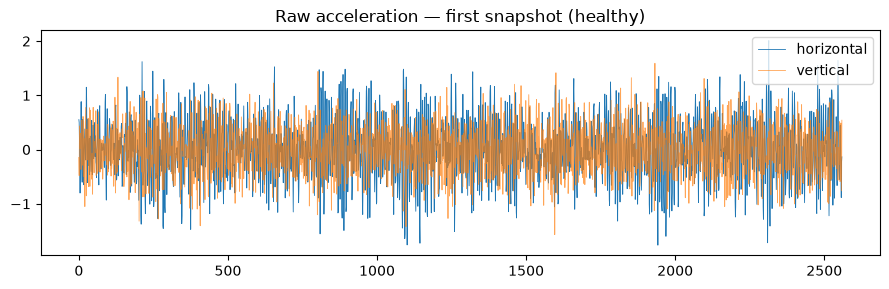

In [2]:
import sys; sys.path.append("..")
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.data_loading import load_snapshot, n_snapshots, _acc_files

bearing = config.DATA_ROOT / "Learning_set" / "Bearing1_1"   # adjust to your layout
print("snapshots in this bearing:", n_snapshots(bearing))

snap = load_snapshot(_acc_files(bearing)[0])
print("one snapshot shape:", snap.shape)   # (2560, 2)

plt.figure(figsize=(9,3))
plt.plot(snap[:,0], lw=0.6, label="horizontal")
plt.plot(snap[:,1], lw=0.6, label="vertical", alpha=0.7)
plt.title("Raw acceleration — first snapshot (healthy)"); plt.legend(); plt.tight_layout()

## 2. Health indicators over life

RMS is energy; kurtosis is spikiness (rises early when a spall starts hitting a
rolling element). Watch how they stay flat for most of the bearing's life, then
climb sharply near failure — that flat region is *why* linear RUL is misleading.

(2803, 35)


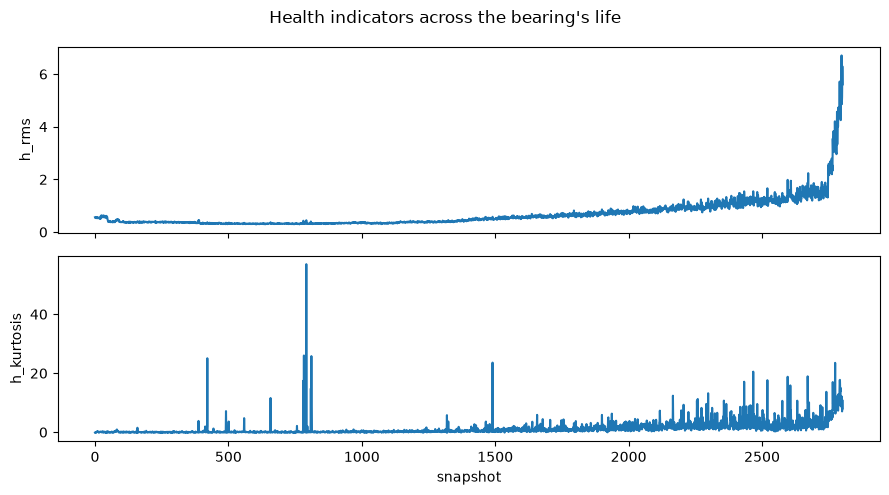

In [2]:
from src.features import build_feature_frame
df = build_feature_frame(bearing)     # one row per snapshot (cached in results/)
print(df.shape)

fig, ax = plt.subplots(2,1, figsize=(9,5), sharex=True)
ax[0].plot(df["h_rms"]);      ax[0].set_ylabel("h_rms")
ax[1].plot(df["h_kurtosis"]); ax[1].set_ylabel("h_kurtosis"); ax[1].set_xlabel("snapshot")
fig.suptitle("Health indicators across the bearing's life"); fig.tight_layout()

## 3. The labelling decision — linear vs piecewise

**Linear RUL** = `total_life − t`: a straight line. It claims the bearing is
already dying at t=0. During the long flat health region above, this forces the
model to predict a specific countdown from a signal that carries no degradation
information yet — it learns position-in-file, not physics.

**Piecewise-linear RUL**: flat plateau until a detected degradation onset (First
Prediction Time), then a linear ramp to zero. This says RUL only becomes a
meaningful countdown once damage is detectable.

Where the knee sits is an *event-detection* problem on the health trajectory.
The detector below is a transparent baseline (RMS leaving a healthy band); a
proper event-driven labeller is the obvious upgrade.

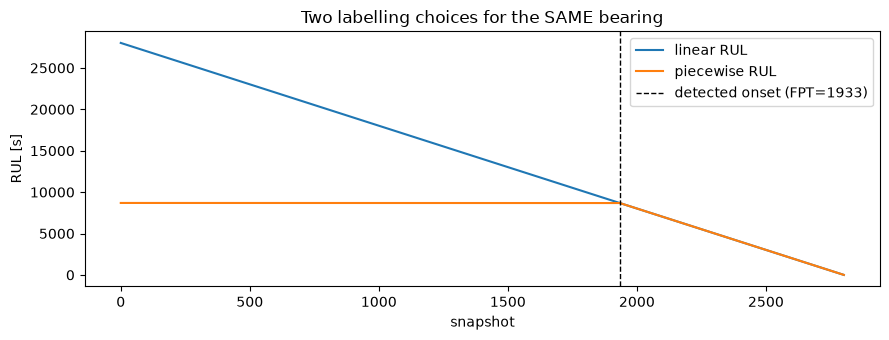

In [3]:
from src.labeling import linear_rul, piecewise_rul, detect_fpt

n = len(df)
fpt = detect_fpt(df["h_rms"].to_numpy())
lin = linear_rul(n)
pw  = piecewise_rul(n, fpt)

plt.figure(figsize=(9,3.5))
plt.plot(lin, label="linear RUL")
plt.plot(pw,  label="piecewise RUL")
plt.axvline(fpt, color="k", ls="--", lw=1, label=f"detected onset (FPT={fpt})")
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend()
plt.title("Two labelling choices for the SAME bearing"); plt.tight_layout()

Text(0.5, 1.0, 'Bearing1_3 — XGBoost')

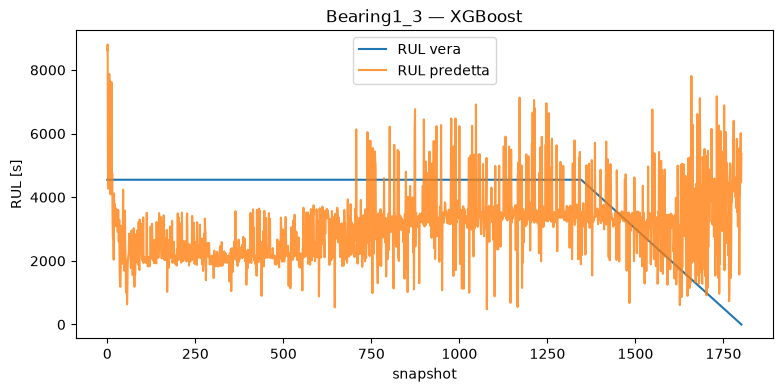

In [13]:
import numpy as np, matplotlib.pyplot as plt
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler

train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1","Bearing3_2"]
train_data = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, cache=False) for n in train_names}
scalers, cols = fit_scalers(train_data)

Xtr = np.concatenate([apply_scaler(n, df, scalers, cols) for n,(df,_) in train_data.items()])
ytr = np.concatenate([t for _,t in train_data.values()])
model = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                     subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)

df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/"Bearing1_3", cache=False)
ypred = model.predict(apply_scaler("Bearing1_3", df, scalers, cols))

plt.figure(figsize=(9,4))
plt.plot(ytrue, label="RUL vera")
plt.plot(ypred, label="RUL predetta", alpha=0.8)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title("Bearing1_3 — XGBoost")

## 4. Leakage checklist (before any modelling)

- [ ] split is **by bearing**, never by random snapshot
- [ ] scaler fit on **training bearings only**, applied per operating condition
- [ ] validation bearing (for early stopping) is held out from *training*, not from test
- [ ] sequence windows never cross a bearing boundary

If all four hold, the numbers in the README table mean something. If any fails,
the model looks great and generalises to nothing.

epoch   1 | train       0.04 | val       0.30
epoch   2 | train       0.01 | val       0.36
epoch   3 | train       0.00 | val       0.37
epoch   4 | train       0.00 | val       0.35
epoch   5 | train       0.00 | val       0.35
epoch   6 | train       0.00 | val       0.35
epoch   7 | train       0.00 | val       0.35
epoch   8 | train       0.00 | val       0.35
epoch   9 | train       0.00 | val       0.35
epoch  10 | train       0.00 | val       0.36
epoch  11 | train       0.00 | val       0.36
early stopping at epoch 11


Text(0.5, 1.0, 'Bearing1_3 — LSTM')

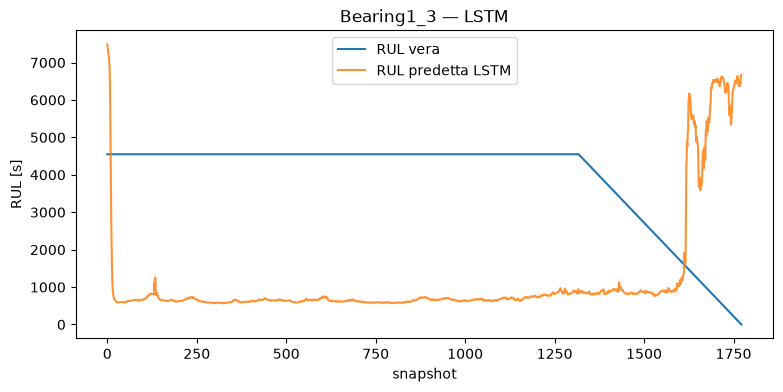

In [15]:
import numpy as np, matplotlib.pyplot as plt, torch
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from torch.utils.data import DataLoader
from src.dataset import SequenceDataset

RUL_SCALE = 1.0/9000.0
WINDOW = 30
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]  # 5 per fit
val_name = "Bearing3_2"
tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)

def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
train_ds = SequenceDataset(pairs(tr), window=WINDOW)
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, cache=False)}
val_ds = SequenceDataset(pairs(vd), window=WINDOW)

model = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(model, DataLoader(train_ds,128,shuffle=True), DataLoader(val_ds,128), epochs=100)
model = out["model"]; device = get_device(); model.eval()

df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/"Bearing1_3", cache=False)
X,_ = make_sequences(apply_scaler("Bearing1_3",df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
with torch.no_grad():
    pred = model(torch.from_numpy(X).to(device)).cpu().numpy()/RUL_SCALE

plt.figure(figsize=(9,4))
plt.plot(ytrue[WINDOW-1:], label="RUL vera")
plt.plot(pred, label="RUL predetta LSTM", alpha=0.85)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title("Bearing1_3 — LSTM")

Text(0.5, 1.0, "Target 'capped' — cap fisso a 5000s")

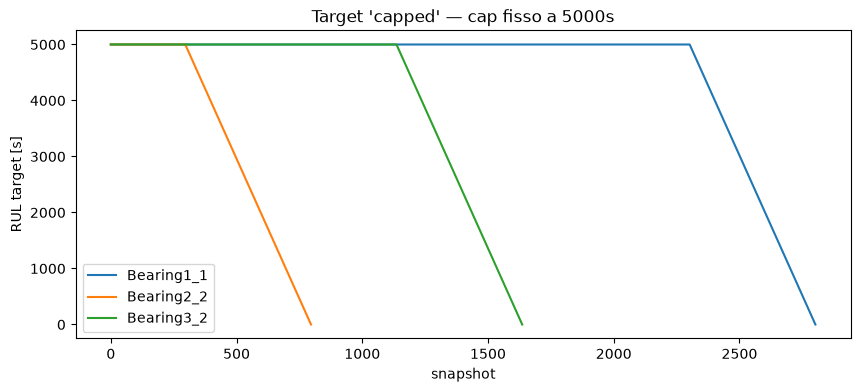

In [2]:
import numpy as np, matplotlib.pyplot as plt
from src import config
from src.features import build_feature_frame
from src.labeling import make_targets

names = ["Bearing1_1","Bearing2_2","Bearing3_2"]  # i tre casi più diversi
plt.figure(figsize=(10,4))
for n in names:
    df = build_feature_frame(config.DATA_ROOT/"Learning_set"/n)
    t = make_targets(df, mode="capped")
    plt.plot(t, label=n)
plt.xlabel("snapshot"); plt.ylabel("RUL target [s]"); plt.legend()
plt.title("Target 'capped' — cap fisso a 5000s")

epoch   1 | train       0.02 | val       0.02
epoch   2 | train       0.00 | val       0.01
epoch   3 | train       0.00 | val       0.01
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
epoch  14 | train       0.00 | val       0.00
epoch  15 | train       0.00 | val       0.00
epoch  16 | train       0.00 | val       0.00
epoch  17 | train       0.00 | val       0.00
epoch  18 | train       0.00 | val       0.00
epoch  19 | train       0.00 | val       0.00
epoch  20 | train       0.00 | val       0.00
epoch  21 | train       0.00 | val       0.00
epoch  22 | train       0.00 | val

Text(0.5, 1.0, 'Bearing1_3 — LSTM (capped)')

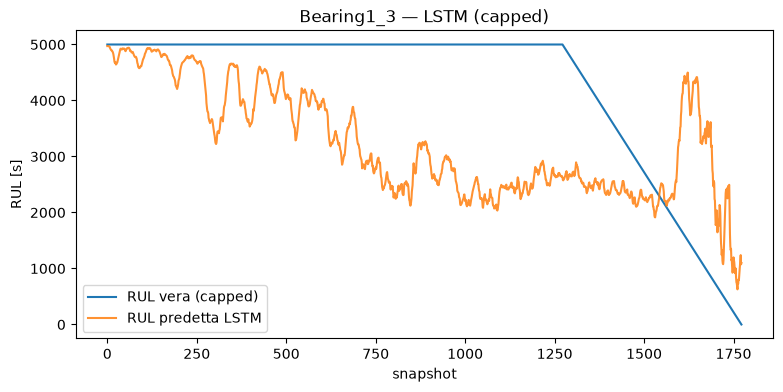

In [3]:
import numpy as np, matplotlib.pyplot as plt, torch
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from torch.utils.data import DataLoader

RUL_SCALE = 1.0/9000.0
WINDOW = 30
MODE = "capped"
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"
tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
train_ds = SequenceDataset(pairs(tr), window=WINDOW)
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
val_ds = SequenceDataset(pairs(vd), window=WINDOW)
model = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(model, DataLoader(train_ds,128,shuffle=True), DataLoader(val_ds,128), epochs=100)
model = out["model"]; device = get_device(); model.eval()

df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/"Bearing1_3", label_mode=MODE, cache=False)
X,_ = make_sequences(apply_scaler("Bearing1_3",df,scalers,cols), ytrue*RUL_SCALE, window=WINDOW)
with torch.no_grad():
    pred = model(torch.from_numpy(X).to(device)).cpu().numpy()/RUL_SCALE
plt.figure(figsize=(9,4))
plt.plot(ytrue[WINDOW-1:], label="RUL vera (capped)")
plt.plot(pred, label="RUL predetta LSTM", alpha=0.85)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title("Bearing1_3 — LSTM (capped)")

epoch   1 | train       0.04 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
epoch  14 | train       0.00 | val       0.00
epoch  15 | train       0.00 | val       0.00
epoch  16 | train       0.00 | val       0.00
epoch  17 | train       0.00 | val       0.00
epoch  18 | train       0.00 | val       0.00
epoch  19 | train       0.00 | val       0.00
epoch  20 | train       0.00 | val       0.00
early stopping at epoch 20
           RMSE      MAE     PHM(traiettoria)
XGBoost

Text(0.5, 1.0, 'Bearing1_3 — confronto')

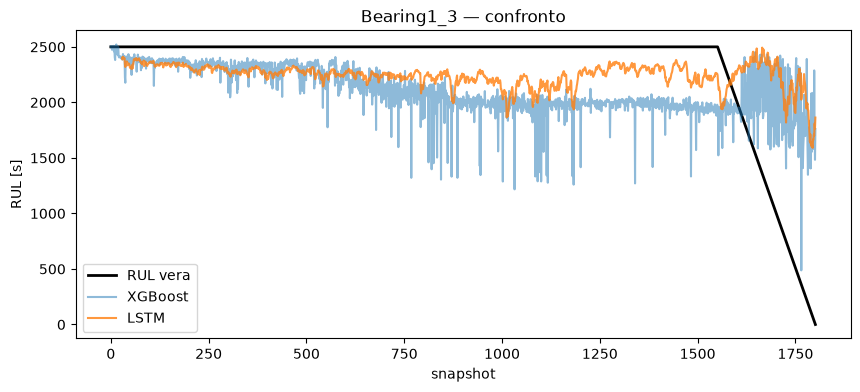

In [3]:
import numpy as np, matplotlib.pyplot as plt, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.evaluate import rmse, mae, phm_score
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW, MODE = 1.0/9000.0, 30, "capped"
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name, test_name = "Bearing3_2", "Bearing1_3"

tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)

# --- XGBoost ---
Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
ytr = np.concatenate([t for _,t in tr.values()])
xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)

# --- LSTM ---
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
lstm = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(lstm, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                  DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
lstm = out["model"]; dev = get_device(); lstm.eval()

# --- predizioni sul test ---
df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/test_name, label_mode=MODE, cache=False)
Xs = apply_scaler(test_name, df, scalers, cols)
xgb_pred = xgb.predict(Xs)
Xseq,_ = make_sequences(Xs, ytrue*RUL_SCALE, window=WINDOW)
with torch.no_grad():
    lstm_pred = lstm(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
yt_aligned = ytrue[WINDOW-1:]

print("           RMSE      MAE     PHM(traiettoria)")
print(f"XGBoost   {rmse(ytrue,xgb_pred):7.0f}  {mae(ytrue,xgb_pred):7.0f}   {phm_score(ytrue,xgb_pred):.3f}")
print(f"LSTM      {rmse(yt_aligned,lstm_pred):7.0f}  {mae(yt_aligned,lstm_pred):7.0f}   {phm_score(yt_aligned,lstm_pred):.3f}")

plt.figure(figsize=(10,4))
plt.plot(ytrue, "k", label="RUL vera", lw=2)
plt.plot(xgb_pred, label="XGBoost", alpha=0.5)
plt.plot(range(WINDOW-1, WINDOW-1+len(lstm_pred)), lstm_pred, label="LSTM", alpha=0.8)
plt.xlabel("snapshot"); plt.ylabel("RUL [s]"); plt.legend(); plt.title(f"{test_name} — confronto")

In [3]:
import numpy as np, torch
from xgboost import XGBRegressor
from src import config
from src.pipeline import prepare_bearing, fit_scalers, apply_scaler
from src.dataset import make_sequences, SequenceDataset
from src.models import RULRegressorRNN
from src.train import train_model, get_device
from src.evaluate import rmse, mae, phm_score
from torch.utils.data import DataLoader

RUL_SCALE, WINDOW, MODE, CAP = 1.0/9000.0, 30, "capped", 2500.0
train_names = ["Bearing1_1","Bearing1_2","Bearing2_1","Bearing2_2","Bearing3_1"]
val_name = "Bearing3_2"
test_names = ["Bearing1_3","Bearing2_3","Bearing3_3"]

tr = {n: prepare_bearing(config.DATA_ROOT/"Learning_set"/n, label_mode=MODE, cache=False) for n in train_names}
scalers, cols = fit_scalers(tr)

# XGBoost
Xtr = np.concatenate([apply_scaler(n,df,scalers,cols) for n,(df,_) in tr.items()])
ytr = np.concatenate([t for _,t in tr.values()])
xgb = XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.03,
                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42).fit(Xtr, ytr)

# LSTM
def pairs(d): return [(apply_scaler(n,df,scalers,cols), t*RUL_SCALE) for n,(df,t) in d.items()]
vd = {val_name: prepare_bearing(config.DATA_ROOT/"Learning_set"/val_name, label_mode=MODE, cache=False)}
lstm = RULRegressorRNN(input_size=len(cols), hidden_size=64, num_layers=2, rnn_type="lstm")
out = train_model(lstm, DataLoader(SequenceDataset(pairs(tr),WINDOW),128,shuffle=True),
                  DataLoader(SequenceDataset(pairs(vd),WINDOW),128), epochs=100)
lstm = out["model"]; dev = get_device(); lstm.eval()

def eval_bearing(name):
    df, ytrue = prepare_bearing(config.DATA_ROOT/"Test_set"/name, label_mode=MODE, cache=False)
    Xs = apply_scaler(name, df, scalers, cols)
    xp = xgb.predict(Xs)
    Xseq,_ = make_sequences(Xs, ytrue*RUL_SCALE, window=WINDOW)
    with torch.no_grad():
        lp = lstm(torch.from_numpy(Xseq).to(dev)).cpu().numpy()/RUL_SCALE
    yl = ytrue[WINDOW-1:]
    dx, dl = ytrue < CAP, yl < CAP
    return {
        "xgb_full": (rmse(ytrue,xp), mae(ytrue,xp), phm_score(ytrue,xp)),
        "lstm_full": (rmse(yl,lp), mae(yl,lp), phm_score(yl,lp)),
        "xgb_degr": (rmse(ytrue[dx],xp[dx]), phm_score(ytrue[dx],xp[dx])),
        "lstm_degr": (rmse(yl[dl],lp[dl]), phm_score(yl[dl],lp[dl])),
    }

print(f"{'Bearing':<12}{'XGB RMSE':>10}{'LSTM RMSE':>11}{'XGB PHM':>10}{'LSTM PHM':>10}  | degrado RMSE  XGB/LSTM")
for n in test_names:
    r = eval_bearing(n)
    print(f"{n:<12}{r['xgb_full'][0]:>10.0f}{r['lstm_full'][0]:>11.0f}"
          f"{r['xgb_full'][2]:>10.3f}{r['lstm_full'][2]:>10.3f}"
          f"  | {r['xgb_degr'][0]:>8.0f} / {r['lstm_degr'][0]:.0f}")

epoch   1 | train       0.03 | val       0.00
epoch   2 | train       0.00 | val       0.00
epoch   3 | train       0.00 | val       0.00
epoch   4 | train       0.00 | val       0.00
epoch   5 | train       0.00 | val       0.00
epoch   6 | train       0.00 | val       0.00
epoch   7 | train       0.00 | val       0.00
epoch   8 | train       0.00 | val       0.00
epoch   9 | train       0.00 | val       0.00
epoch  10 | train       0.00 | val       0.00
epoch  11 | train       0.00 | val       0.00
epoch  12 | train       0.00 | val       0.00
epoch  13 | train       0.00 | val       0.00
epoch  14 | train       0.00 | val       0.00
epoch  15 | train       0.00 | val       0.00
epoch  16 | train       0.00 | val       0.00
epoch  17 | train       0.00 | val       0.00
epoch  18 | train       0.00 | val       0.00
epoch  19 | train       0.00 | val       0.00
early stopping at epoch 19
Bearing       XGB RMSE  LSTM RMSE   XGB PHM  LSTM PHM  | degrado RMSE  XGB/LSTM
Bearing1_3         